In [7]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

### GARCH

In [ ]:
# Example of downloading GARCH

from compare.baseline_garch import run_garch_baseline

garch_df_fast, garch_metrics_fast = run_garch_baseline(
    csv_path="dataset_finance_fred_full/eval_csv_with_context/gfc_2008_2010_with_context.csv",
    warmup=256,
    horizon=64,
    step=1,
    mean_type="AR",
    p=1,
    q=1,
    dist="normal",
    aggregate_mode="none",
    n_jobs=8,
    refit_every=5,
    show_progress=True,
    save_path="results/garch/gfc_h64s1.csv",
)


### Simple Baselines (ols, ridge, pls, pcr, rf)

In [ ]:
from compare.baselines import run_panel_baseline

df_rf, metrics_rf = run_panel_baseline(
    csv_path="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    model_name="ols", # [ols, ridge, pls, pcr, rf]
    context_length=256,
    horizon=1,
    step=1,
    include_market=True,
    include_macro=True,
    n_jobs_outer=8, # let's speed this thing up =)
    save_path="results/baselines/ols/inf_h1.csv",
)
print(metrics_rf)

### Creating dataframes

We need a unique style of dataframes to easily compute metrics and plot graphics. Also, in case of horizon != window (step) we need to aggregate data properly.

`duplicate_mode` - parameter allows to define what type of aggreagtion is needed [mean, last, first]. In case, if data doen't need aggregation 'last' will be a proper choice.

In [ ]:
# Exanmple of creating proper dataframe from file with predictions

from compare.download_predictions import load_predictions

dl_df = load_predictions('results/mamba_fred_full/inf_p64.npz', duplicate_mode='last')
garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')

### Computing metrics

There is a lot of metrics, that can be commputed and looked at to undestand the quality of predictions. The once that are highlighted in the diploma are `huber`, `rmse`, `sign accuracy`.
All other metrics, their formulas and some explanation can be found in the file `compare/metrics_explanation.ipynb`.

In [ ]:
# Example of computing metrics for several models' predictions

from compare.compute_metrics import compute_metrics_from_dataframe
from compare.download_predictions import load_predictions
import pandas as pd

paths = {'fred_full': 'mamba_fred_full', 'no_activity': 'mamba_fred_no_activity', 'no_rates': 'mamba_fred_no_rates', 'no_fred': 'mamba_no_fred', 'time_moe': 'time_moe'}
crisis_file = 'gfc_p64.npz'
results = dict()
for key, path in paths.items():
    full_path = f'results/{path}/{crisis_file}'
    df = load_predictions(full_path, duplicate_mode='last')
    metrics = compute_metrics_from_dataframe(df)
    results[key] = metrics

df_results = pd.DataFrame.from_dict(results, orient='index')
df_results

### Plotting 

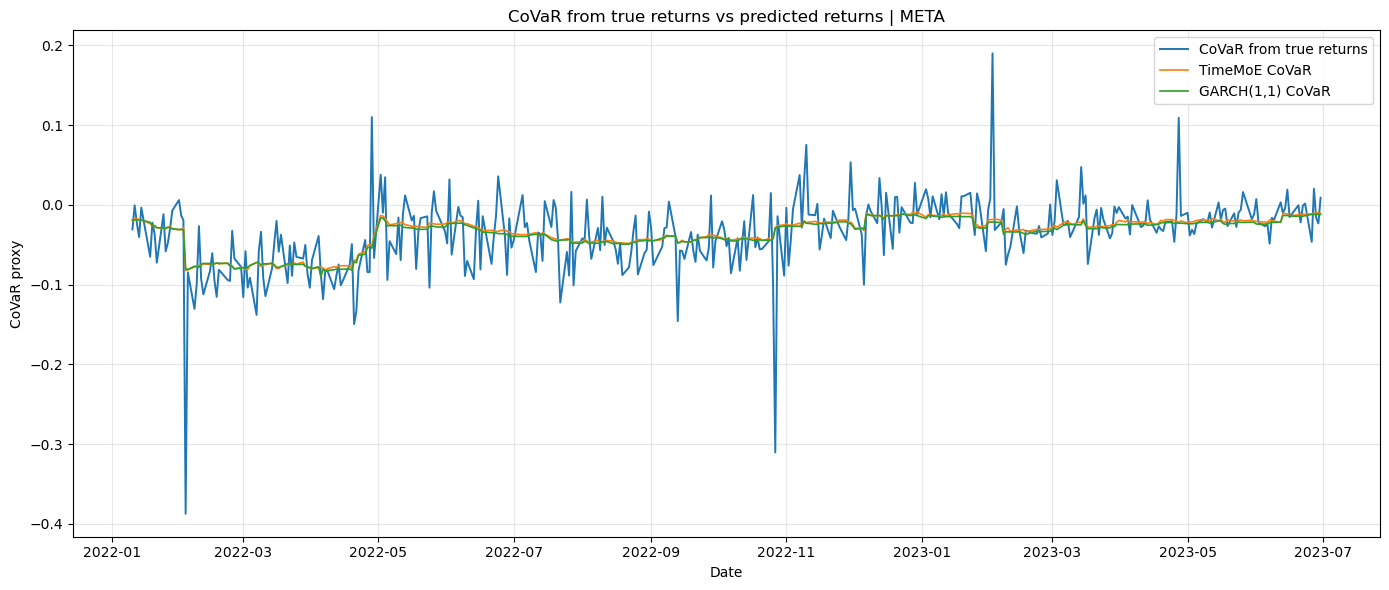

In [ ]:
from compare.plot_graphics import plot_covar_true_vs_predicted
from compare.download_predictions import load_predictions

dl_df = load_predictions('results/mamba_fred_full/inf_p64.npz', duplicate_mode='last')
garch_df = load_predictions('results/garch/inf_h64s64.csv', duplicate_mode='last')


plot_covar_true_vs_predicted(
    df_1=dl_df,
    df_2=garch_df,
    panel="dataset_finance_fred_full/eval_csv_with_context/inflation_2022_2023_with_context.csv",
    model_1_name="TimeMoE",
    model_2_name="GARCH(1,1)",
    ticker="META",
    start_date="2022-01-10",
    end_date="2023-06-30",
    aggregate_mode="last",
    q=0.05,
)